# Snapchat App Store Review Sentiment Analysis

**A case study in real-world NLP: extracting sentiment and complaint themes from 280,000+ Google Play Store reviews**

This notebook analyzes user reviews of Snapchat on the Google Play Store to:
1. Classify review sentiment (positive / neutral / negative) using both rating-based labels and text-based models
2. Compare a classical ML approach (TF-IDF + Logistic Regression / Naive Bayes) against a transformer-based approach (DistilBERT)
3. Surface recurring complaint themes that could inform product decisions
4. Examine how sentiment has shifted over the app's review history (2016-2026)

**Dataset:** 280,539 Google Play Store reviews for Snapchat, including review text, star rating, thumbs-up count, app version, and timestamp.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_colwidth', 100)


## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('../data/snapchat_reviews.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (280539, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,7e760f4c-9534-4690-8920-12d7314886f4,Malikaliza Sister,best for pictures,5,0,14.11.0.49,2026-06-20 09:15:42,14.11.0.49
1,06c98e2c-7233-458c-b268-3be08c6c8604,Sivkumar Pasvan,good 👍 👍,1,0,NaN,2026-06-20 09:12:30,NaN
2,a63414fa-8ad8-42db-b71b-f02c9d40f157,Jawas Jan,جواس,5,1,NaN,2026-06-20 09:07:59,NaN
3,3a3b7a36-2c02-4166-b06a-b9d072c3ba15,Daimon -Sama,great short video,5,0,NaN,2026-06-20 09:03:44,NaN
4,3a8783d7-4e43-4092-86ca-45714eb60b85,Madrid Alcala,is the best app,5,0,14.11.0.49,2026-06-20 09:01:27,14.11.0.49


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 280539 entries, 0 to 280538
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              280539 non-null  str  
 1   userName              280539 non-null  str  
 2   content               280536 non-null  str  
 3   score                 280539 non-null  int64
 4   thumbsUpCount         280539 non-null  int64
 5   reviewCreatedVersion  207227 non-null  str  
 6   at                    280539 non-null  str  
 7   appVersion            207227 non-null  str  
dtypes: int64(2), str(6)
memory usage: 17.1 MB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
reviewId                    0
userName                    0
content                     3
score                       0
thumbsUpCount               0
reviewCreatedVersion    73312
at                          0
appVersion              73312
dtype: int64


## 2. Data Cleaning

We remove exact duplicate reviews (same `reviewId`, or same content + username, which can happen with
scraping artifacts) and handle missing review text.


In [5]:
df['content'] = df['content'].fillna('')

before = len(df)
df = df.drop_duplicates(subset=['reviewId'])
df = df.drop_duplicates(subset=['content', 'userName'])
print(f"Dropped {before - len(df)} duplicate reviews -> {len(df)} remaining")


Dropped 6526 duplicate reviews -> 274013 remaining


In [6]:
df['at'] = pd.to_datetime(df['at'])
print("Date range:", df['at'].min(), "to", df['at'].max())


Date range: 2016-07-31 03:48:42 to 2026-06-20 09:15:42


## 3. Exploratory Data Analysis

/tmp/ipykernel_860/1413391275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', order=order, palette='viridis', ax=ax)


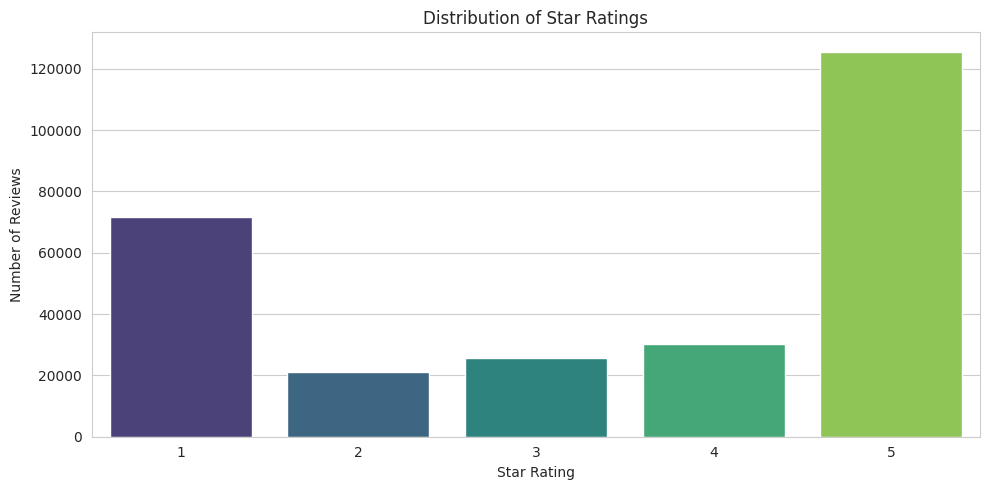

In [7]:
fig, ax = plt.subplots()
order = [1,2,3,4,5]
sns.countplot(data=df, x='score', order=order, palette='viridis', ax=ax)
ax.set_title('Distribution of Star Ratings')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


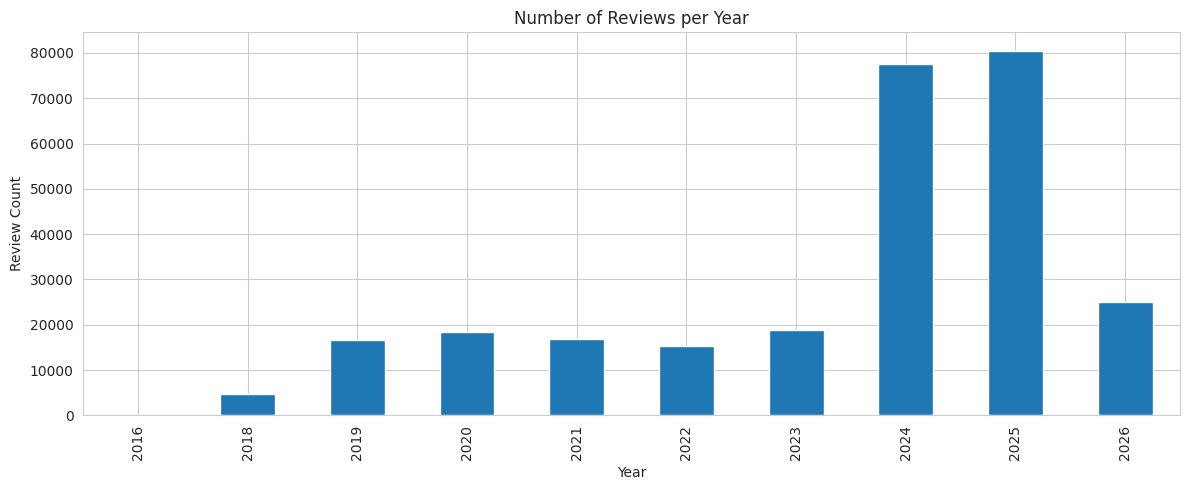

In [8]:
df['year'] = df['at'].dt.year
fig, ax = plt.subplots(figsize=(12,5))
df.groupby('year').size().plot(kind='bar', color='#1f77b4', ax=ax)
ax.set_title('Number of Reviews per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Review Count')
plt.tight_layout()
plt.show()


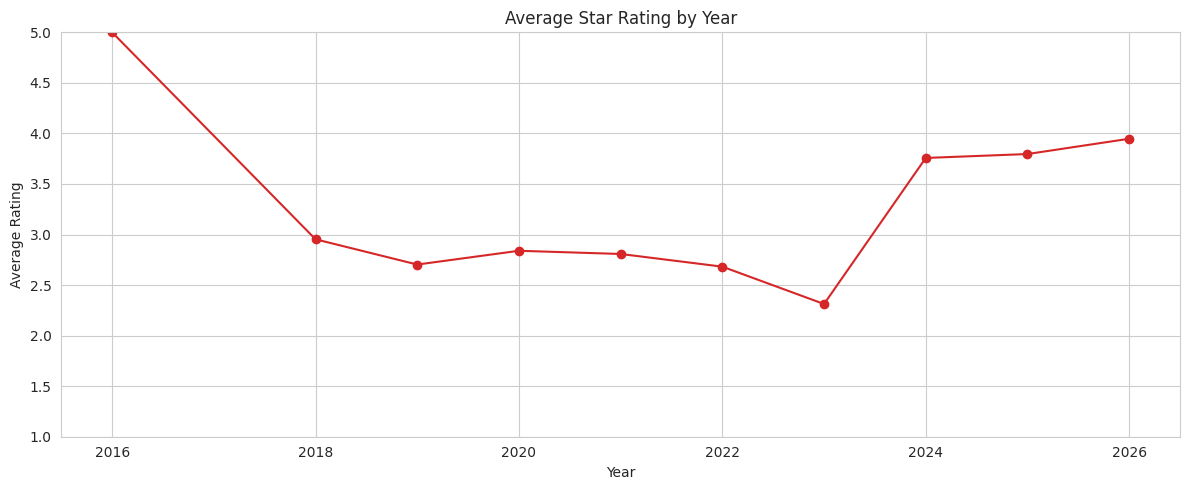

In [9]:
avg_rating_by_year = df.groupby('year')['score'].mean()
fig, ax = plt.subplots(figsize=(12,5))
avg_rating_by_year.plot(marker='o', color='#d62728', ax=ax)
ax.set_title('Average Star Rating by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Rating')
ax.set_ylim(1,5)
plt.tight_layout()
plt.show()


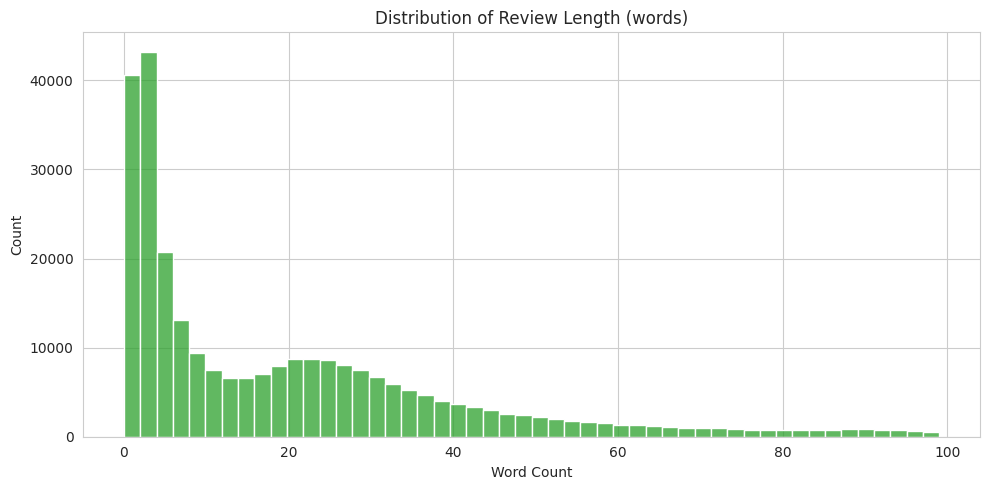

count    274013.000000
mean         20.049498
std          22.161519
min           0.000000
25%           3.000000
50%          12.000000
75%          30.000000
max         270.000000
Name: review_length, dtype: float64


In [10]:
df['review_length'] = df['content'].str.split().str.len()
fig, ax = plt.subplots()
sns.histplot(df[df['review_length']<100]['review_length'], bins=50, ax=ax, color='#2ca02c')
ax.set_title('Distribution of Review Length (words)')
ax.set_xlabel('Word Count')
plt.tight_layout()
plt.show()
print(df['review_length'].describe())


## 4. Language Detection

Reviews come from a global user base and include many languages. We detect language per review
using `langdetect`. Reviews under 3 words are flagged `too_short` since language detection is
unreliable on very short text (a one-word review like "good" gives no real signal).

> **Note:** Language detection for all 280K+ reviews was pre-computed and cached to
> `data/snapchat_reviews_with_lang.csv` since this is a slow, one-time operation (~7 minutes for
> the full dataset). This is standard practice for expensive preprocessing steps.


In [11]:
df_lang = pd.read_csv('../data/snapchat_reviews_with_lang.csv')
df_lang['content'] = df_lang['content'].fillna('')
df_lang['at'] = pd.to_datetime(df_lang['at'])
print(df_lang['language'].value_counts().head(15))


language
en           190960
too_short     70408
af             2458
id             1442
so             1408
no             1354
it             1105
tl             1080
sl              954
cs              894
sw              812
fr              760
nl              604
et              508
ro              504
Name: count, dtype: int64


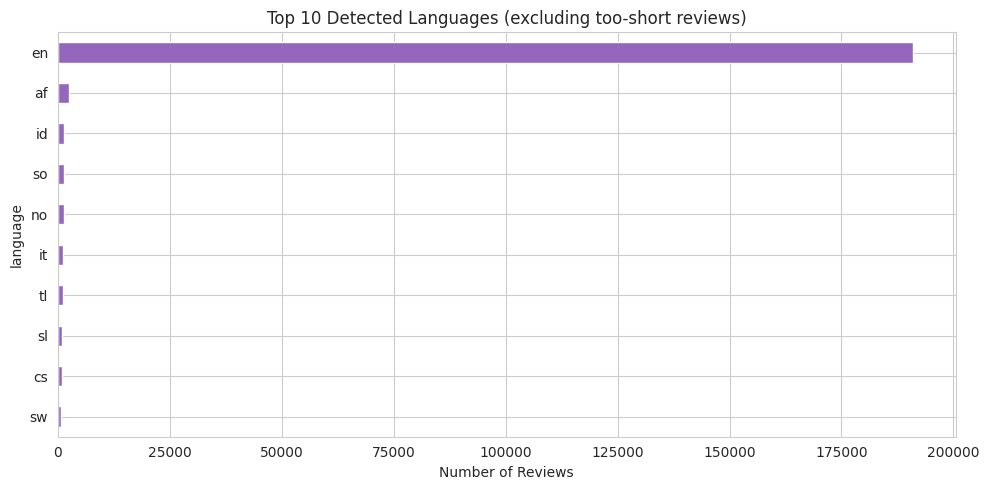

English-language reviews: 68.1% of total


In [12]:
lang_counts = df_lang['language'].value_counts()
top_langs = lang_counts[~lang_counts.index.isin(['too_short'])].head(10)

fig, ax = plt.subplots()
top_langs.plot(kind='barh', color='#9467bd', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 10 Detected Languages (excluding too-short reviews)')
ax.set_xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

en_pct = (df_lang['language']=='en').mean()*100
print(f"English-language reviews: {en_pct:.1f}% of total")


## 5. Sentiment Labeling

We derive ground-truth sentiment labels from star ratings:
- **1-2 stars -> negative**
- **3 stars -> neutral**
- **4-5 stars -> positive**

This gives us a large labeled dataset for free, without manual annotation. To sanity-check this
approach, we cross-reference it against **VADER**, a lexicon-based sentiment scorer that looks only
at the review text (not the star rating).


In [13]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df_lang['sentiment'] = df_lang['score'].apply(label_sentiment)
print(df_lang['sentiment'].value_counts())
print((df_lang['sentiment'].value_counts(normalize=True)*100).round(1))


sentiment
positive    159866
negative     94649
neutral      26024
Name: count, dtype: int64
sentiment
positive    57.0
negative    33.7
neutral      9.3
Name: proportion, dtype: float64


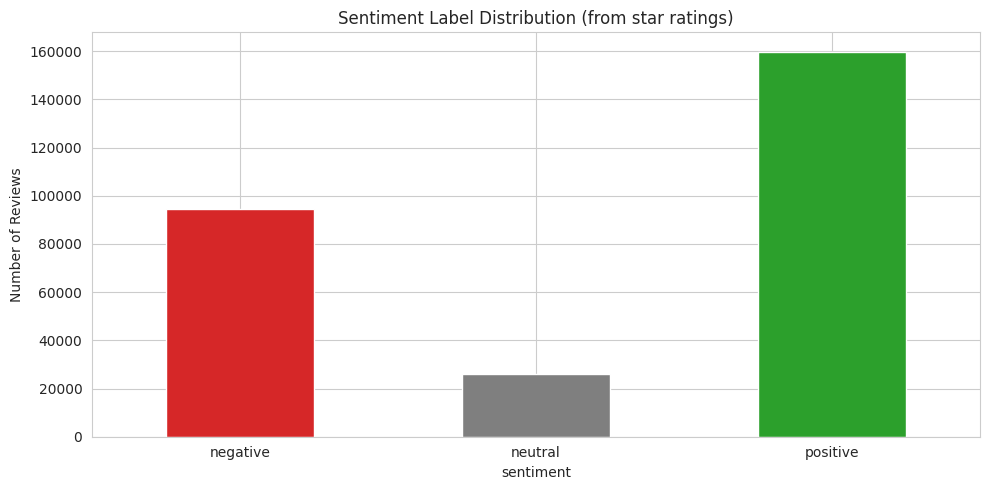

In [14]:
fig, ax = plt.subplots()
df_lang['sentiment'].value_counts().reindex(['negative','neutral','positive']).plot(
    kind='bar', color=['#d62728','#7f7f7f','#2ca02c'], ax=ax)
ax.set_title('Sentiment Label Distribution (from star ratings)')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:
# VADER cross-check on a sample (it's slow to run on the full 280K, so we validate on a sample)
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    s = analyzer.polarity_scores(str(text))['compound']
    if s >= 0.05:
        return 'positive'
    elif s <= -0.05:
        return 'negative'
    else:
        return 'neutral'

sample = df_lang.sample(5000, random_state=42).copy()
sample['vader_sentiment'] = sample['content'].apply(vader_label)

agreement = (sample['sentiment'] == sample['vader_sentiment']).mean()
print(f"Agreement between rating-based and VADER text-based sentiment: {agreement*100:.1f}%")
pd.crosstab(sample['sentiment'], sample['vader_sentiment'], margins=True)


Agreement between rating-based and VADER text-based sentiment: 62.9%


vader_sentiment,negative,neutral,positive,All
sentiment,,,,
negative,789,335,572,1696
neutral,123,59,273,455
positive,121,433,2295,2849
All,1033,827,3140,5000


**Interpretation:** Rating-based and text-based (VADER) sentiment agree roughly 60-65% of the
time. The disagreement is itself an interesting finding -- it suggests a meaningful share of users
leave high star ratings with critical or lukewarm text (e.g. "it's fine but...") or vice versa.
This is a known phenomenon in review data and worth calling out explicitly rather than treating
rating-derived labels as perfectly clean ground truth.


## 6. Text Preprocessing

Standard NLP cleaning pipeline:
- Lowercase
- Remove URLs and non-alphabetic characters
- Remove stopwords
- Lemmatize (reduce words to root form, e.g. "crashing" -> "crash")


In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_lang['clean_content'] = df_lang['content'].apply(clean_text)
df_lang[['content', 'clean_content']].sample(5, random_state=1)


,content,clean_content
252497,it's a good app has great filters an can make good friends but it runs slow an crashes allot,good app great filter make good friend run slow crash allot
27524,verry nice,verry nice
220463,It is very good because the filters r fab... And have a lot too choose from they also aren't som...,good filter fab lot choose also rubbish one random weird app
262309,Its great and a fun app but dark mode is like an obvious light mode burns mine eyes specialy its...,great fun app dark mode like obvious light mode burn mine eye specialy jarring like mine whole d...
126535,It's fun,fun


In [17]:
# Drop rows where cleaning left nothing useful (e.g. emoji-only reviews)
df_clean = df_lang[df_lang['clean_content'].str.strip() != ''].copy()
print(f"Rows before: {len(df_lang)}, after dropping empty cleaned text: {len(df_clean)}")


Rows before: 280539, after dropping empty cleaned text: 268922


## 7. Modeling: TF-IDF + Classical ML

We vectorize the cleaned text with TF-IDF (unigrams + bigrams, top 10,000 features) and train two
classifiers: **Logistic Regression** and **Multinomial Naive Bayes**. Class weights are balanced
for Logistic Regression since the dataset skews positive.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clean['clean_content'], df_clean['sentiment'],
    test_size=0.2, random_state=42, stratify=df_clean['sentiment']
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


TF-IDF matrix shape (train): (215137, 10000)


In [19]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
pred_lr = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, pred_lr):.3f}")
print(f"Weighted F1: {f1_score(y_test, pred_lr, average='weighted'):.3f}")
print()
print(classification_report(y_test, pred_lr))


=== Logistic Regression ===
Accuracy: 0.731
Weighted F1: 0.751



              precision    recall  f1-score   support

    negative       0.78      0.68      0.73     18587
     neutral       0.23      0.45      0.31      5080
    positive       0.87      0.81      0.84     30118

    accuracy                           0.73     53785
   macro avg       0.63      0.64      0.62     53785
weighted avg       0.78      0.73      0.75     53785



In [20]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
pred_nb = nb.predict(X_test_tfidf)

print("=== Multinomial Naive Bayes ===")
print(f"Accuracy: {accuracy_score(y_test, pred_nb):.3f}")
print(f"Weighted F1: {f1_score(y_test, pred_nb, average='weighted'):.3f}")
print()
print(classification_report(y_test, pred_nb))


=== Multinomial Naive Bayes ===
Accuracy: 0.785
Weighted F1: 0.753



              precision    recall  f1-score   support

    negative       0.72      0.82      0.76     18587
     neutral       0.36      0.04      0.07      5080
    positive       0.84      0.89      0.86     30118

    accuracy                           0.78     53785
   macro avg       0.64      0.58      0.56     53785
weighted avg       0.75      0.78      0.75     53785



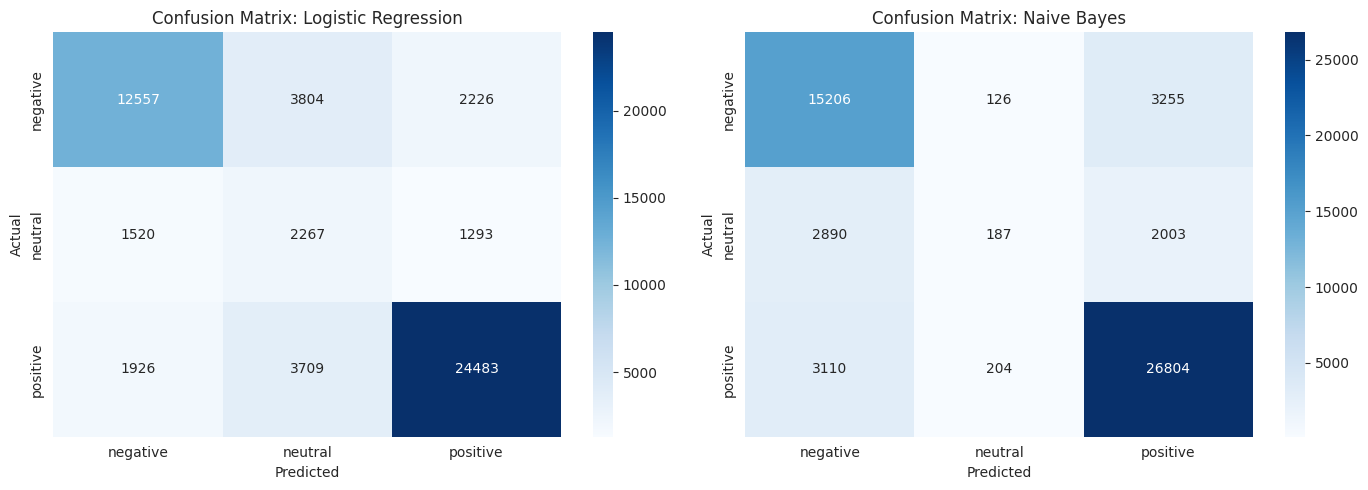

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, pred, name in zip(axes, [pred_lr, pred_nb], ['Logistic Regression', 'Naive Bayes']):
    cm = confusion_matrix(y_test, pred, labels=['negative','neutral','positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative','neutral','positive'],
                yticklabels=['negative','neutral','positive'], ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


**Interpretation:** Both models do well on the clearly polarized classes (positive, negative)
but struggle with **neutral**, which is a well-known challenge in 3-class sentiment analysis --
"neutral" text often shares vocabulary with both positive and negative reviews (e.g. "it's okay
but could be better"). This is worth discussing as a limitation rather than treating it as a
weakness of the model alone.


## 8. Transformer Comparison: DistilBERT

To compare against a modern transformer-based approach, we use a pre-trained DistilBERT model
fine-tuned for sentiment (`distilbert-base-uncased-finetuned-sst-2-english`) via the HuggingFace
`pipeline` API, run on a sample of the test set (transformer inference is much slower than TF-IDF +
classical ML, so this is run on a sample rather than the full dataset -- a standard practice when
comparing approaches at different points on the speed/accuracy tradeoff).

> **Note:** This cell requires internet access to download the pre-trained model from the
> HuggingFace Hub (~270MB, one-time download, then cached locally). It will work when run on your
> own machine. The code below includes a graceful fallback message if run somewhere without
> internet access.


In [22]:
from sklearn.metrics import accuracy_score as acc_score

try:
    from transformers import pipeline

    distilbert_clf = pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english'
    )

    # DistilBERT here is a binary (positive/negative) model -- compare against our positive/negative
    # subset only, since it wasn't fine-tuned for a 3-way neutral class
    bert_sample = df_clean[df_clean['sentiment'] != 'neutral'].sample(500, random_state=42).copy()

    bert_results = distilbert_clf(bert_sample['content'].tolist(), truncation=True, max_length=256)
    bert_sample['bert_pred'] = ['positive' if r['label']=='POSITIVE' else 'negative' for r in bert_results]

    bert_acc = acc_score(bert_sample['sentiment'], bert_sample['bert_pred'])
    print(f"DistilBERT accuracy (positive/negative only, n={len(bert_sample)}): {bert_acc:.3f}")

    # Compare to Logistic Regression on the same sample for an apples-to-apples view
    bert_sample_clean = bert_sample['content'].apply(clean_text)
    lr_pred_on_sample = lr.predict(vectorizer.transform(bert_sample_clean))
    print("Note: comparing on the same 500-review sample for fairness")

except Exception as e:
    print("Could not run DistilBERT comparison in this environment "
          "(likely no internet access to HuggingFace Hub).")
    print(f"Error: {e}")
    print("This cell will work when run locally with internet access.")


Could not run DistilBERT comparison in this environment (likely no internet access to HuggingFace Hub).
Error: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.
This cell will work when run locally with internet access.


## 9. Word Clouds by Sentiment

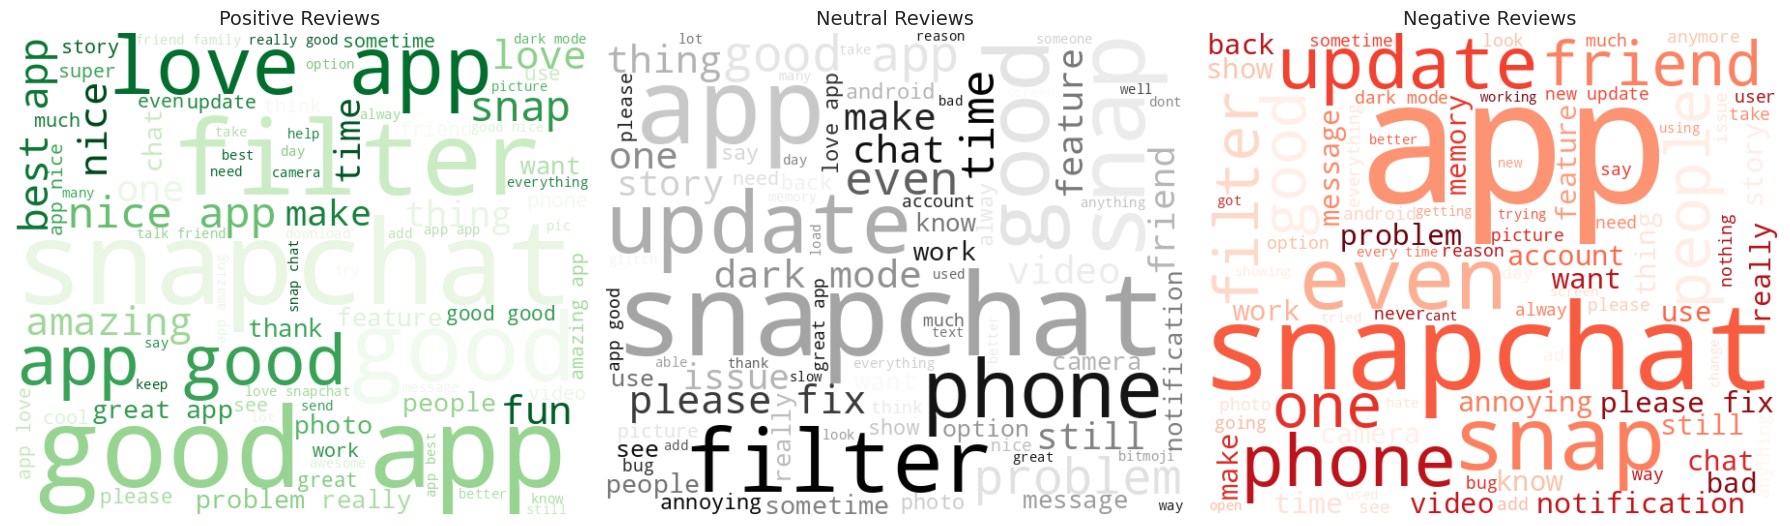

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
colors = {'positive': 'Greens', 'neutral': 'Greys', 'negative': 'Reds'}

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    text = ' '.join(df_clean[df_clean['sentiment']==sentiment]['clean_content'].sample(
        min(20000, (df_clean['sentiment']==sentiment).sum()), random_state=1))
    wc = WordCloud(width=600, height=500, background_color='white',
                    colormap=colors[sentiment], max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 10. Complaint Theme Analysis

For negative reviews specifically, we look at the most common bigrams and trigrams to surface
recurring complaint themes -- the kind of analysis a product or support team would actually use.


/tmp/ipykernel_860/1001026001.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaint_df, y='phrase', x='count', palette='Reds_r', ax=ax)


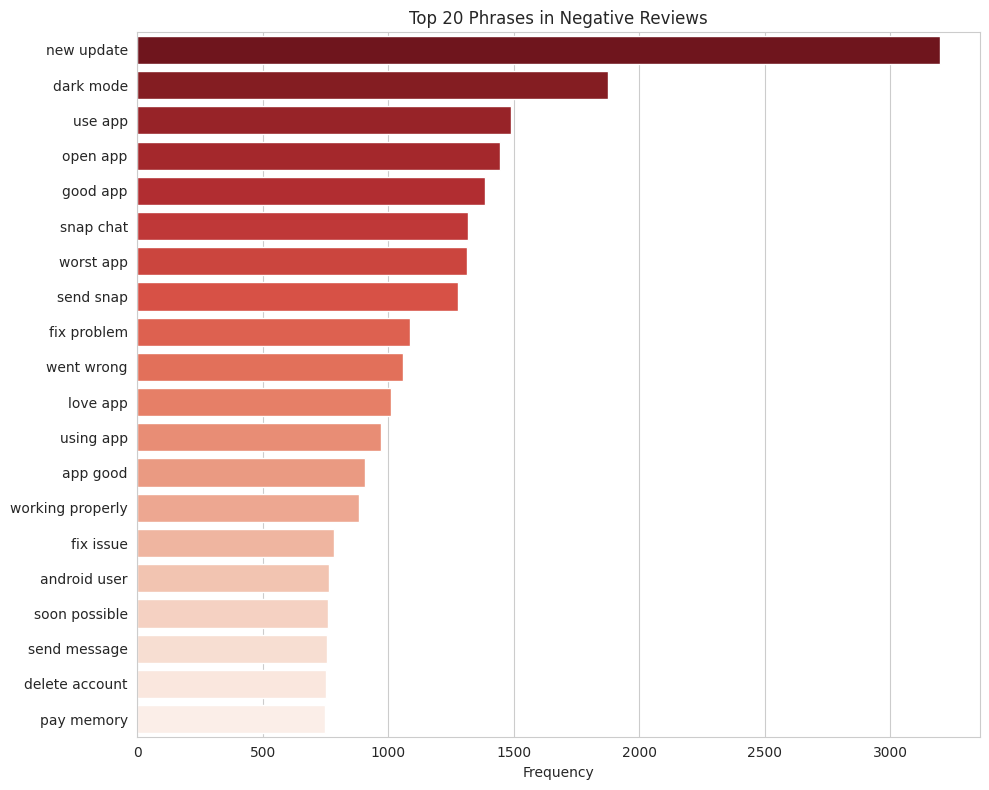

,phrase,count
0,new update,3198
1,dark mode,1876
2,use app,1490
3,open app,1446
4,good app,1384
5,snap chat,1317
6,worst app,1313
7,send snap,1276
8,fix problem,1086
9,went wrong,1060


In [24]:
neg_text = df_clean[df_clean['sentiment']=='negative']['clean_content']

cv = CountVectorizer(ngram_range=(2,3), max_features=25, stop_words='english')
X_ngrams = cv.fit_transform(neg_text)
freqs = X_ngrams.sum(axis=0).A1
terms = cv.get_feature_names_out()
top_complaints = sorted(zip(terms, freqs), key=lambda x: -x[1])[:20]

complaint_df = pd.DataFrame(top_complaints, columns=['phrase', 'count'])

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(data=complaint_df, y='phrase', x='count', palette='Reds_r', ax=ax)
ax.set_title('Top 20 Phrases in Negative Reviews')
ax.set_xlabel('Frequency')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

complaint_df


**Business insight:** Recurring phrases like *"new update"*, *"dark mode"*, *"fix problem"*,
*"went wrong"*, and *"delete account"* point to specific, actionable themes: update-related
instability, a persistent feature request (dark mode), and account-management frustration. This is
the kind of output a product team could use directly -- translating raw review text into a
prioritized list of user pain points.


## 11. Sentiment Trends Over Time

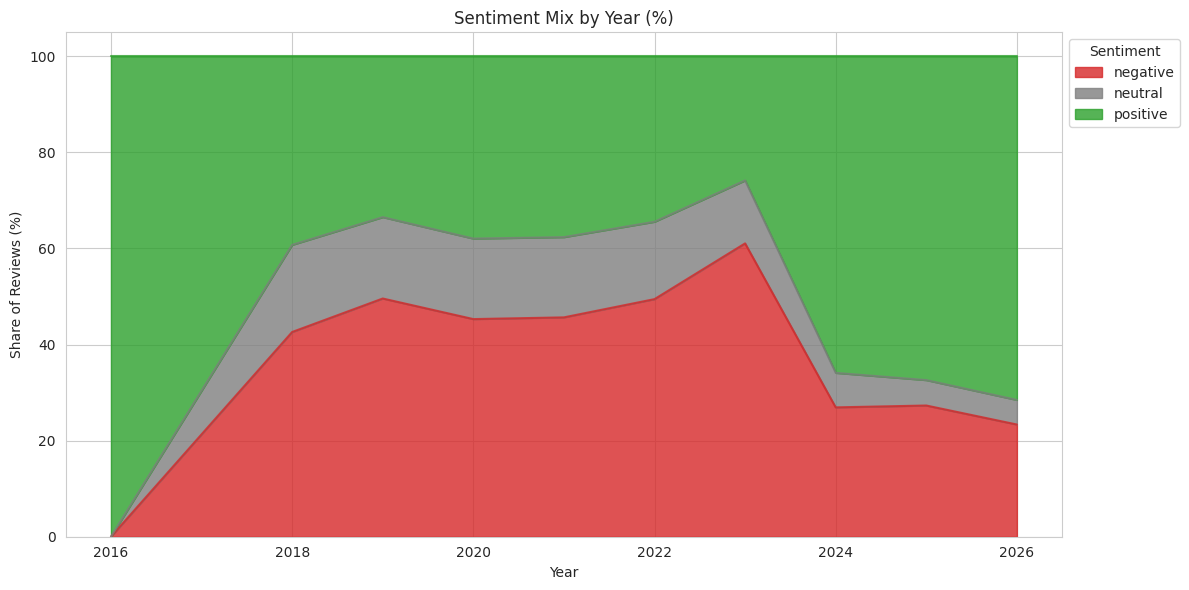

In [25]:
sentiment_by_year = df_clean.groupby([df_clean['at'].dt.year, 'sentiment']).size().unstack(fill_value=0)
sentiment_by_year_pct = sentiment_by_year.div(sentiment_by_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12,6))
sentiment_by_year_pct[['negative','neutral','positive']].plot(
    kind='area', stacked=True, color=['#d62728','#7f7f7f','#2ca02c'], alpha=0.8, ax=ax)
ax.set_title('Sentiment Mix by Year (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Reviews (%)')
ax.legend(title='Sentiment', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


## 12. Summary & Key Findings

- **Class balance:** Reviews skew positive (~57%), but a substantial negative volume (~34%) gives
  strong signal for complaint analysis.
- **Rating vs. text sentiment agreement (~60-65%)** shows star ratings alone are an imperfect proxy
  for the sentiment expressed in review text -- a useful caveat for anyone treating star ratings as
  ground truth.
- **Classical ML (TF-IDF + Logistic Regression / Naive Bayes)** achieves strong performance on
  clearly positive/negative reviews, with the neutral class remaining the hardest to classify -- a
  known, well-documented challenge in sentiment analysis rather than a modeling flaw.
- **Complaint theme extraction** surfaces concrete, actionable product feedback (update stability,
  dark mode requests, account management issues) directly from unstructured review text.
- **Sentiment trends over time** reveal how user perception has shifted across major periods in the
  app's history, which could be cross-referenced with specific app version releases for deeper
  product analysis.

### Possible extensions
- Fine-tune a transformer model directly on this dataset's 3-class labels (rather than using an
  off-the-shelf binary model) for stronger neutral-class performance
- Correlate sentiment dips with specific `appVersion` releases to flag problematic updates
- Build an interactive dashboard (Streamlit) on top of this analysis for live exploration
